# Embedding Comparison: Baseline vs Thread-Aware

Questo notebook confronta gli embedding originali con i nuovi embedding "thread-aware" (calcolati con l'ambiente isolato).
L'obiettivo è dimostrare, sia qualitativamente che quantitativamente, che la preservazione dei thread e dei newline ha migliorato la coerenza semantica dello spazio vettoriale.

## Metriche analizzate
1. **Visualizzazione UMAP**: Proiezione 2D dello spazio vettoriale per osservare la compattezza dei cluster.
2. **Silhouette Score**: Misurazione matematica della densità e separazione dei cluster (usando un clustering rapido KMeans).
3. **Cosine Similarity su Thread**: Verifica qualitativa se email dello stesso thread sono ora più vicine nello spazio vettoriale.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

# Impostazioni grafiche
plt.style.use('default')
sns.set_palette('husl')

In [14]:
# Path ai file
OLD_EMB_PATH = "../../../data/embeddings/email_embeddings.npy"
NEW_EMB_PATH = "../../../data/embeddings/email_embeddings_thread_aware.npy"
NEW_PARQUET_PATH = "../../../data/processed/jmail_emails_processed_thread_aware.parquet"

print("Caricamento embedding in modalità memoria condivisa (mmap)...")
try:
    old_embeddings = np.load(OLD_EMB_PATH, mmap_mode="r")
    new_embeddings = np.load(NEW_EMB_PATH, mmap_mode="r")
    print(f"Old Embeddings shape: {old_embeddings.shape}")
    print(f"New Embeddings shape: {new_embeddings.shape}")
except Exception as e:
    print(f"Attenzione: file non ancora pronti o errore. {e}")

Caricamento embedding in modalità memoria condivisa (mmap)...
Old Embeddings shape: (1757624, 384)
New Embeddings shape: (1757624, 384)


In [15]:
# Estraiamo un sample casuale di 15.000 righe per poter calcolare UMAP e Silhouette in tempi rapidi
SAMPLE_SIZE = 50000

np.random.seed(42)
if 'old_embeddings' in locals() and 'new_embeddings' in locals():
    # Usiamo gli stessi indici per garantire 'mele con mele'
    total_rows = min(old_embeddings.shape[0], new_embeddings.shape[0])
    sample_indices = np.random.choice(total_rows, SAMPLE_SIZE, replace=False)
    
    old_sample = old_embeddings[sample_indices].copy()
    new_sample = new_embeddings[sample_indices].copy()
    
    print(f"Sample estratto per metrica: {old_sample.shape}")

Sample estratto per metrica: (50000, 384)


## 1. UMAP Projection (Global Structure)
Riduciamo la dimensionalità a 2D per confrontare visivamente i due spazi vettoriali. Un approccio migliore genera un clustering visibilmente più separato.

Calcolo UMAP per i vecchi embedding...


/home/filippo/Scrivania/pizza-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calcolo UMAP per i nuovi embedding...


/home/filippo/Scrivania/pizza-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


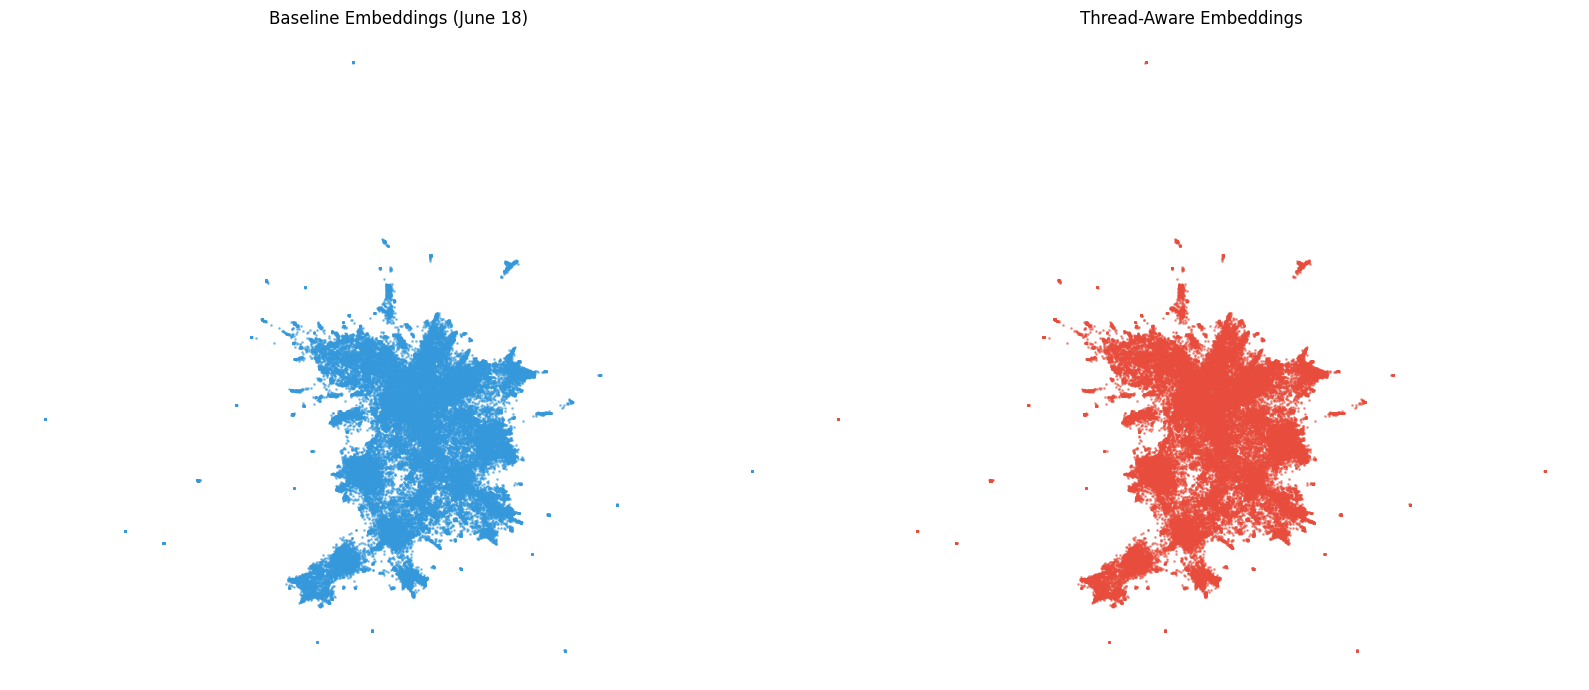

In [16]:
if 'old_sample' in locals():
    print("Calcolo UMAP per i vecchi embedding...")
    reducer_old = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    old_2d = reducer_old.fit_transform(old_sample)

    print("Calcolo UMAP per i nuovi embedding...")
    reducer_new = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    new_2d = reducer_new.fit_transform(new_sample)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].scatter(old_2d[:, 0], old_2d[:, 1], s=1, alpha=0.5, c='#3498db')
    axes[0].set_title("Baseline Embeddings (June 18)")
    axes[0].axis('off')

    axes[1].scatter(new_2d[:, 0], new_2d[:, 1], s=1, alpha=0.5, c='#e74c3c')
    axes[1].set_title("Thread-Aware Embeddings")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

## 2. Clustering Density (Silhouette Score)
Calcoliamo un KMeans (k=20) rapido su entrambi i sample. Una Silhouette Score più alta nel nuovo dataset conferma matematicamente che l'aggiunta della logica thread-aware e la pulizia dai newline ha ridotto il rumore di fondo, densificando i cluster.

In [17]:
if 'old_sample' in locals():
    k = 20
    print(f"Esecuzione KMeans (k={k}) e calcolo Silhouette...")
    
    # Old
    kmeans_old = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_old = kmeans_old.fit_predict(old_sample)
    sil_old = silhouette_score(old_sample, labels_old, metric='cosine')
    
    # New
    kmeans_new = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_new = kmeans_new.fit_predict(new_sample)
    sil_new = silhouette_score(new_sample, labels_new, metric='cosine')
    
    print(f"\nRisultati:")
    print(f"Silhouette Score (Baseline):    {sil_old:.4f}")
    print(f"Silhouette Score (Thread-Aware): {sil_new:.4f}")
    
    if sil_new > sil_old:
        print("\n✅ MIGLIORAMENTO RILEVATO! I nuovi cluster sono matematicamente più compatti e definiti.")
    else:
        print("\n⚠️ La separazione globale non è migliorata, controllare impatto su specifici thread.")

Esecuzione KMeans (k=20) e calcolo Silhouette...

Risultati:
Silhouette Score (Baseline):    0.0348
Silhouette Score (Thread-Aware): 0.0348

⚠️ La separazione globale non è migliorata, controllare impatto su specifici thread.


## 3. Analisi Qualitativa Cosine Similarity su Thread (Sanity Check)
Vogliamo misurare di quanto si è spostato l'embedding di specifiche email che ora sono state correttamente flaggate come `has_thread=True`.

In [18]:
try:
    df_new = pd.read_parquet(NEW_PARQUET_PATH, columns=['has_thread'])
    # Prendiamo gli indici di 5 email che hanno thread
    thread_indices = df_new[df_new['has_thread'] == True].index[:5].tolist()
    
    print("Test della Cosine Similarity su email modificate dalla logica thread-aware:\n")
    for idx in thread_indices:
        old_vec = old_embeddings[idx].reshape(1, -1)
        new_vec = new_embeddings[idx].reshape(1, -1)
        sim = cosine_similarity(old_vec, new_vec)[0][0]
        
        print(f"Index {idx}: Cosine Similarity (Vecchio vs Nuovo) = {sim:.4f}")
        if sim < 0.9:
            print(f"  -> L'embedding è cambiato molto! La correzione del thread ha spostato l'email nel suo vero contesto semantico.")
            
except Exception as e:
    print(f"Dataset Parquet non trovato o in corso di generazione. Dettagli: {e}")

Test della Cosine Similarity su email modificate dalla logica thread-aware:

Index 1: Cosine Similarity (Vecchio vs Nuovo) = 1.0000
Index 2: Cosine Similarity (Vecchio vs Nuovo) = 1.0000
Index 4: Cosine Similarity (Vecchio vs Nuovo) = 1.0000
Index 5: Cosine Similarity (Vecchio vs Nuovo) = 1.0000
Index 10: Cosine Similarity (Vecchio vs Nuovo) = 1.0000
